
# Part 1 — Netflix Dataset, MongoDB Atlas, and Analytical Querying

Course: Database Management Tools in Python | Spring 2026

Dataset used: `netflix_titles.csv`



## Import Required Libraries


In [1]:

import pandas as pd
import numpy as np
from pymongo import MongoClient
import matplotlib.pyplot as plt

plt.style.use('ggplot')



## Load Dataset


In [2]:

df = pd.read_csv('netflix_titles.csv')

print(df.head())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:

print('Dataset Shape:', df.shape)
print(df.columns)


Dataset Shape: (8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [4]:

print(df.isnull().sum())


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64



# Data Cleaning and Preparation


In [5]:

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['date_added'] = df['date_added'].fillna('Unknown')

df.drop_duplicates(inplace=True)

df['genre_list'] = df['listed_in'].apply(
    lambda x: [i.strip() for i in str(x).split(',')]
)

df['country_list'] = df['country'].apply(
    lambda x: [i.strip() for i in str(x).split(',')]
)

print(df[['listed_in', 'genre_list']].head())


                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Shows, International TV Shows, TV Act...   
3                             Docuseries, Reality TV   
4  International TV Shows, Romantic TV Shows, TV ...   

                                          genre_list  
0                                    [Documentaries]  
1  [International TV Shows, TV Dramas, TV Mysteries]  
2  [Crime TV Shows, International TV Shows, TV Ac...  
3                           [Docuseries, Reality TV]  
4  [International TV Shows, Romantic TV Shows, TV...  



# Database Technology Comparison

## SQLite
- Relational database
- Best for structured tabular data
- Requires normalization

## MongoDB Atlas
- Document-oriented database
- Flexible schema
- Arrays work naturally for genres and countries
- Excellent for aggregation pipelines

## Neo4j
- Graph database
- Excellent for relationship traversal
- More suitable for relationship-heavy analytics

# Selected Database: MongoDB Atlas

MongoDB Atlas was selected because:

1. Netflix titles naturally fit document structures.
2. Genres and countries can be stored as arrays.
3. Flexible schema simplifies modelling.
4. Aggregation pipelines support analytical queries efficiently.
5. No need for multiple normalization tables.



# MongoDB Collection Design

Each Netflix title is stored as one MongoDB document.

Example structure:

```json
{
    "show_id": "s1",
    "type": "Movie",
    "title": "Example",
    "genre_list": ["Drama", "Comedy"],
    "country_list": ["United States", "India"]
}
```



# Indexing Discussion

## Index 1: release_year
Improves yearly trend analysis.

## Index 2: genre_list
Improves aggregation and filtering by genres.

## Index 3: country_list
Improves aggregation and filtering by countries.



# Connect Python to MongoDB Atlas

Replace the connection string below with your own MongoDB Atlas URI.


In [21]:
from getpass import getpass
from dotenv import load_dotenv
import os

# load MONGO_URI from a .env file.

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

print("Connection string loaded. For security, it is not displayed here.")

Connection string loaded. For security, it is not displayed here.


In [22]:

from pymongo import MongoClient

client = MongoClient(MONGO_URI)

try:
    client.admin.command("ping")
    print("Successfully connected to MongoDB Atlas!")
except Exception as e:
    print("Connection failed.")
    print(e)

db = client['netflix_database']

collection = db['netflix_titles']

print('MongoDB connection successful!')


Successfully connected to MongoDB Atlas!
MongoDB connection successful!



# Insert Data into MongoDB


In [23]:

records = df.to_dict(orient='records')

collection.delete_many({})

collection.insert_many(records)

print('Data inserted successfully!')


Data inserted successfully!



# Create Indexes


In [24]:

collection.create_index('release_year')
collection.create_index('genre_list')
collection.create_index('country_list')

print('Indexes created successfully!')


Indexes created successfully!



# Analytical Query 1 — Most Common Genres


In [25]:

pipeline1 = [
    {'$unwind': '$genre_list'},
    {'$group': {'_id': '$genre_list', 'count': {'$sum': 1}}},
    {'$sort': {'count': -1}},
    {'$limit': 10}
]

genre_results = list(collection.aggregate(pipeline1))

genres_df = pd.DataFrame(genre_results)

genres_df.rename(columns={'_id': 'genre'}, inplace=True)

print(genres_df)


                      genre  count
0      International Movies   2752
1                    Dramas   2427
2                  Comedies   1674
3    International TV Shows   1351
4             Documentaries    869
5        Action & Adventure    859
6                 TV Dramas    763
7        Independent Movies    756
8  Children & Family Movies    641
9           Romantic Movies    616


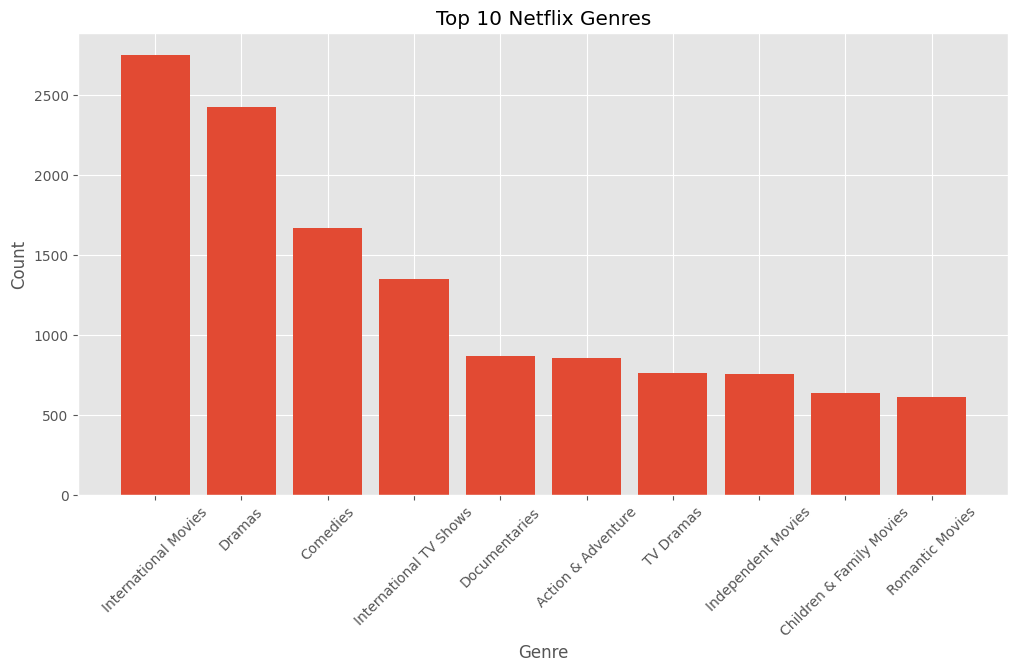

In [26]:

plt.figure(figsize=(12,6))

plt.bar(genres_df['genre'], genres_df['count'])

plt.xticks(rotation=45)

plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Netflix Genres')

plt.show()



### Interpretation

The plot shows that Drama, International Movies, and Comedy are among the most common genres on Netflix.



# Analytical Query 2 — Countries Producing the Most Content


In [27]:

pipeline2 = [
    {'$unwind': '$country_list'},
    {'$group': {'_id': '$country_list', 'count': {'$sum': 1}}},
    {'$sort': {'count': -1}},
    {'$limit': 10}
]

country_results = list(collection.aggregate(pipeline2))

countries_df = pd.DataFrame(country_results)

countries_df.rename(columns={'_id': 'country'}, inplace=True)

print(countries_df)


          country  count
0   United States   3690
1           India   1046
2         Unknown    831
3  United Kingdom    806
4          Canada    445
5          France    393
6           Japan    318
7           Spain    232
8     South Korea    231
9         Germany    226


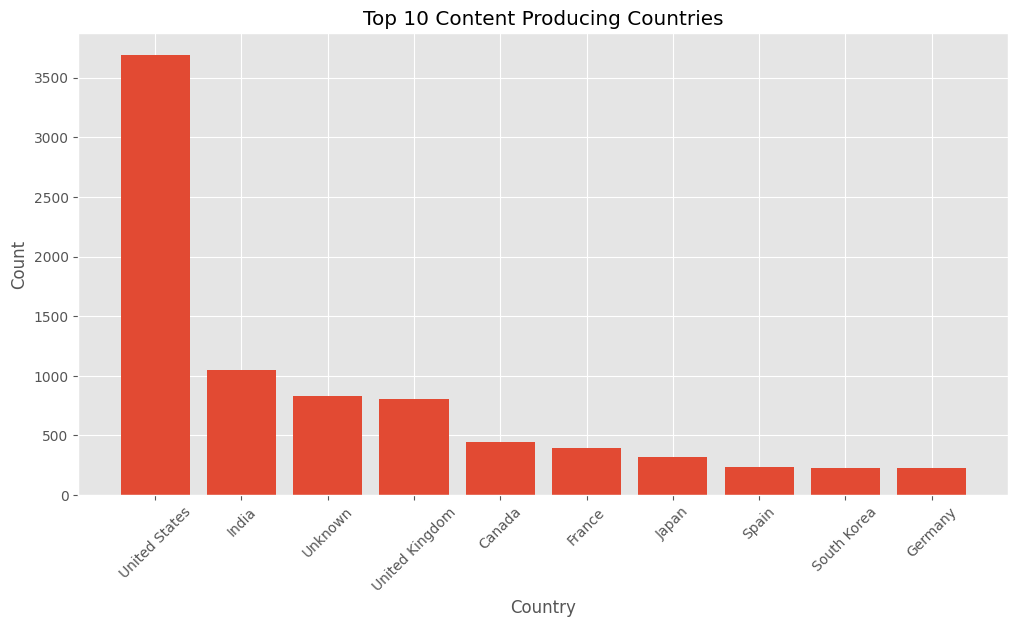

In [28]:

plt.figure(figsize=(12,6))

plt.bar(countries_df['country'], countries_df['count'])

plt.xticks(rotation=45)

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Content Producing Countries')

plt.show()



### Interpretation

The United States produces the highest number of Netflix titles, followed by India and the United Kingdom.



# Analytical Query 3 — Netflix Titles Released Per Year


In [29]:

pipeline3 = [
    {'$group': {'_id': '$release_year', 'count': {'$sum': 1}}},
    {'$sort': {'_id': 1}}
]

release_results = list(collection.aggregate(pipeline3))

release_df = pd.DataFrame(release_results)

release_df.rename(columns={'_id': 'release_year'}, inplace=True)

print(release_df.head())


   release_year  count
0          1925      1
1          1942      2
2          1943      3
3          1944      3
4          1945      4


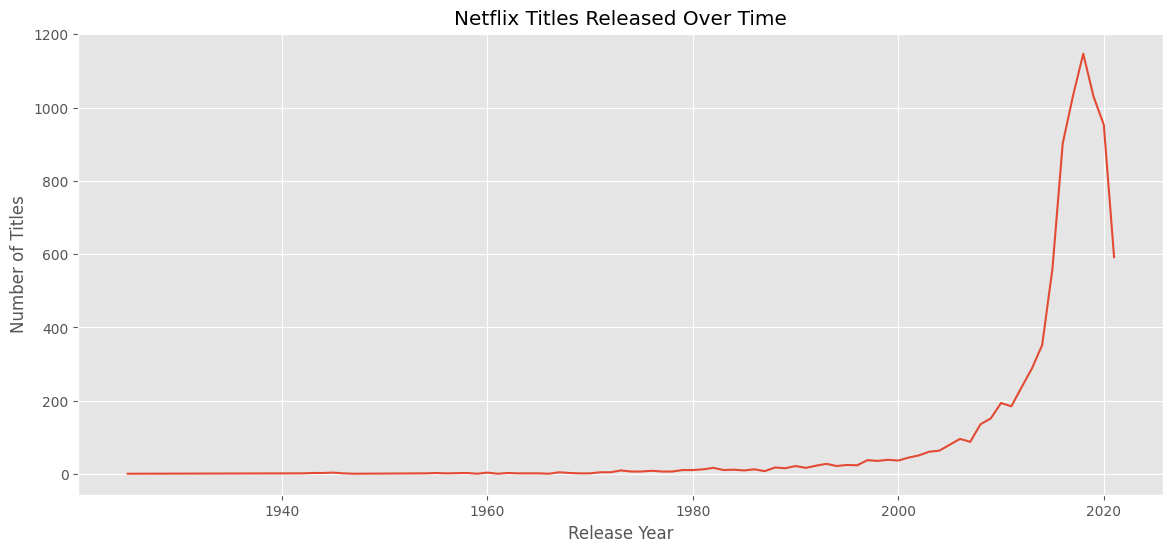

In [30]:

plt.figure(figsize=(14,6))

plt.plot(release_df['release_year'], release_df['count'])

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Netflix Titles Released Over Time')

plt.show()



### Interpretation

Netflix content production increased significantly in recent years, reflecting global expansion and investment in original productions.



# Discussion and Reflection

## Why MongoDB Fits the Dataset
- Flexible document structure
- Arrays simplify repeated values
- Aggregation pipelines support analytics efficiently

## Modelling Repeated Values
Genres and countries were stored as arrays rather than normalized mapping tables.

## MongoDB Advantages
- Flexible schema
- Easy scaling
- Simple document design

## Limitations Compared with SQLite
- Complex joins are harder
- Less normalized

## Limitations Compared with Neo4j
- Relationship traversal is weaker


## Netflix Movie Data Visualization using AI Generated Prompts inside MongoDB Atlas Cluster.

Figure 1: MongoDB Atlas indexes created for release_year, genre_list, and country_list fields.

![Figure 1: MongoDB Atlas indexes](Output_data/mongodb_indexes_configuration.png)

Figure 2: Top content-producing countries on Netflix categorized by content type (Movie vs TV Show).

![Figure 2: Top content producing countries on Netflix](Output_data/mongodb_top_countries_by_content_type.png)

Figure 3: Evolution of Netflix title releases over time based on release_year analysis.

![Figure 3: Evolution of Netflix title releases over time](Output_data/mongodb_release_year_trend_analysis.png)

Figure 4: Rating distribution across Netflix genres for titles released after 2010.

![Figure 1: Rating distribution across Netflix genres for titles after 2010](Output_data/mongodb_genre_rating_distribution_post2010.png)